In [1]:
# Import Libraries
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
# Load Dataset
ratings = pd.read_csv("u.data", sep="\t", names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv("u.item", sep="|", encoding="latin-1", header=None, 
                     names=["movie_id", "title", "release_date", "video_release_date", "IMDb_URL",
                            "unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime", 
                            "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", 
                            "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"])


In [3]:
# Merge datasets
df = pd.merge(ratings, movies[["movie_id", "title", "release_date", "Action", "Comedy", "Drama", "Romance", "Sci-Fi"]], on="movie_id")

In [4]:
# Basic Statistics
print("Dataset Shape:", df.shape)
print("\nRating Summary:\n", df["rating"].describe())

Dataset Shape: (100000, 11)

Rating Summary:
 count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


C:\Users\WELCOME\AppData\Local\Temp\ipykernel_9772\2439788301.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=df, palette="coolwarm")


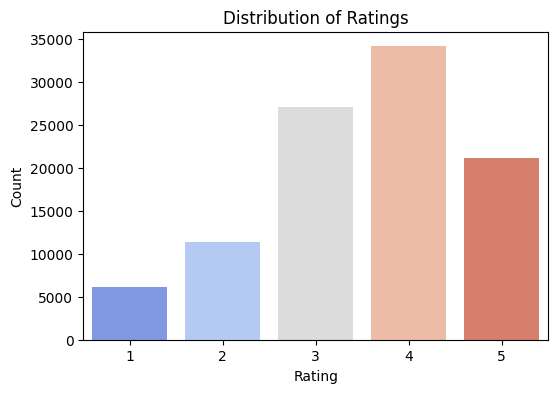

In [5]:
# Visualization 1: Rating Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=df, palette="coolwarm")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

C:\Users\WELCOME\AppData\Local\Temp\ipykernel_9772\140126691.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_rated.index, x=top_rated.values, palette="viridis")


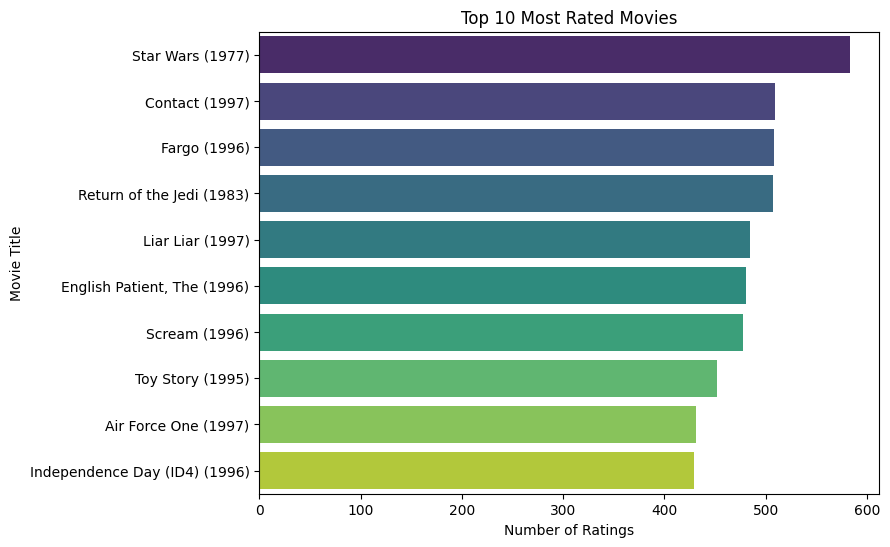

In [6]:
# Visualization 2: Top 10 Most Rated Movies
top_rated = df["title"].value_counts().head(10)
plt.figure(figsize=(8,6))
sns.barplot(y=top_rated.index, x=top_rated.values, palette="viridis")
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()

C:\Users\WELCOME\AppData\Local\Temp\ipykernel_9772\945465921.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_avg.index, x=top_avg["avg_rating"], palette="mako")


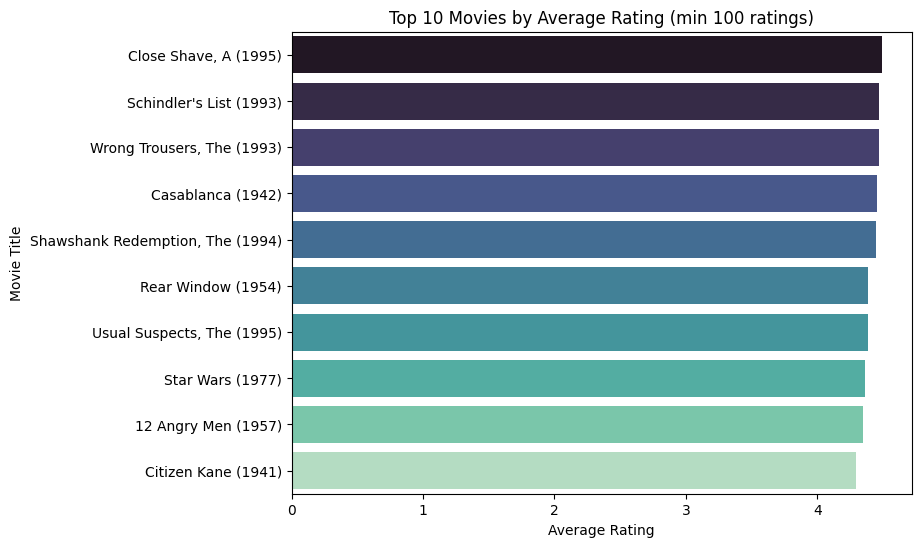

In [7]:
# Visualization 3: Top 10 Movies by Average Rating (with min 100 ratings)
movie_stats = df.groupby("title").agg({"rating": ["mean", "count"]})
movie_stats.columns = ["avg_rating", "num_ratings"]
top_avg = movie_stats[movie_stats["num_ratings"] >= 100].sort_values("avg_rating", ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(y=top_avg.index, x=top_avg["avg_rating"], palette="mako")
plt.title("Top 10 Movies by Average Rating (min 100 ratings)")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.show()

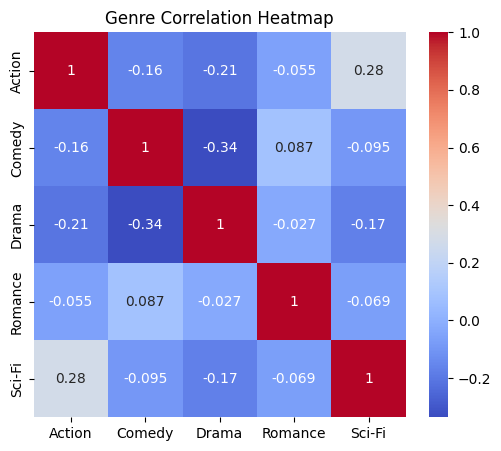

In [8]:
# Visualization 4: Correlation Heatmap (Genres)
genre_cols = ["Action", "Comedy", "Drama", "Romance", "Sci-Fi"]
corr = df.groupby("title")[genre_cols].mean().corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Genre Correlation Heatmap")
plt.show()

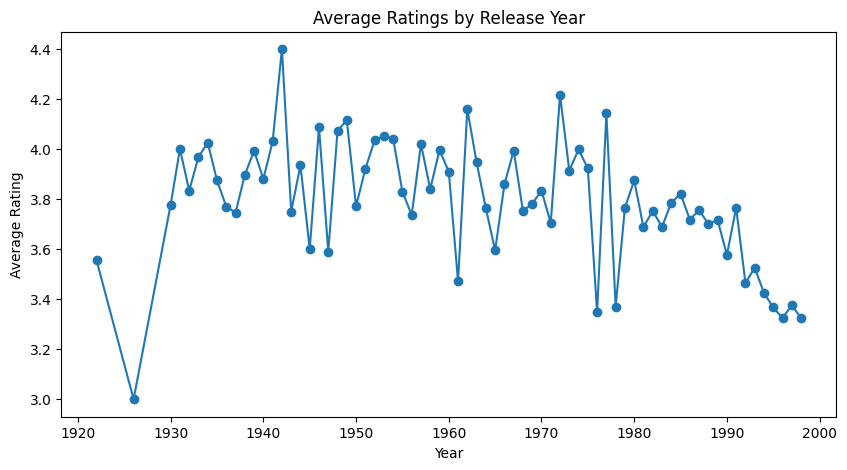

In [9]:
# Visualization 5: Ratings Over Time
df["year"] = df["release_date"].str[-4:]  # extract year
df["year"] = pd.to_numeric(df["year"], errors="coerce")

ratings_by_year = df.groupby("year")["rating"].mean().dropna()

plt.figure(figsize=(10,5))
ratings_by_year.plot(kind="line", marker="o")
plt.title("Average Ratings by Release Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()
